# 03 - Hierarchical Flower Demo

This vignette executes control-plane code and inspects the artifacts produced by
`make demo`. The global model is produced by the global Flower SuperLink, whose clients
are regional gateway SuperNodes. No clinical data exists in this workflow; the local rows
are network-flow telemetry.

In [1]:
from pathlib import Path
import os

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
ROOT

PosixPath('/Users/david/Documents/GitHub/project')

## 1. Hierarchical dry-run commands

In [2]:
import subprocess
import sys
from pathlib import Path
import json
import pandas as pd

cmd = [
    sys.executable,
    "scripts/run_hierarchical_rounds.py",
    "--global-rounds",
    "1",
    "--regional-rounds",
    "1",
    "--batch-size",
    "8192",
    "--dry-run",
]
proc = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True, check=True)
print(proc.stdout)
if proc.stderr:
    print(proc.stderr)

────────────────────────────────────────────────────────────────────────────────────────────────────── Global round 1 ──────────────────────────────────────────────────────────────────────────────────────────────────────
Starting from global checkpoint: shared/checkpoints/global/round_0.pt

Regional phase: region_eu | site_nodes=3 | train_examples=871,173 | regional_rounds=1

Submitting Flower run to region-eu
$ flwr run . region-eu --stream --run-config 'level="regional" region="region_eu" global-round=1 init-checkpoint="/shared/checkpoints/global/round_0.pt" output-checkpoint="/shared/checkpoints/region_eu/round_1.pt" num-server-rounds=1 local-epochs=1 batch-size=8192 learning-rate=0.001 input-dim=78 region-num-examples=871173 fraction-train=1.0 fraction-evaluate=1.0 min-train-nodes=3 min-evaluate-nodes=3 min-available-nodes=3'

Regional phase: region_na | site_nodes=3 | train_examples=1,110,344 | regional_rounds=1

Submitting Flower run to region-na
$ flwr run . region-na --stream -

## 2. Verbose training transcript

`make demo` writes a cleaned transcript to `reports/demo_transcript.txt`. The excerpt
below keeps the process lines: section headers, submitted Flower runs, regional/global
phases, checkpoint writes, evaluation, predictions, and the final metrics summary.

In [3]:
import re

transcript = Path("reports/demo_transcript.txt")
ansi = re.compile(r"\x1B(?:\[[0-?]*[ -/]*[@-~]|\][^\x07]*(?:\x07|\x1B\\)|[@-Z\\-_])")
if transcript.exists():
    lines = ansi.sub("", transcript.read_text(errors="replace")).splitlines()
    interesting = [
        line for line in lines
        if line.startswith("=")
        or line.startswith("Step ")
        or line.startswith("Demo scope")
        or line.startswith("$ ")
        or "Global round" in line
        or "Regional phase:" in line
        or "Global phase:" in line
        or "Submitting Flower run" in line
        or "Checkpoint written:" in line
        or "Latest global checkpoint" in line
        or "weighted_f1" in line
        or "hierarchical_fl" in line
        or "Wrote site metrics" in line
        or "Wrote predictions" in line
    ]
    print("\n".join(interesting[-160:]))
else:
    print("No demo transcript found. Run: make demo")

Demo scope
Step 1/6 - Start local Flower deployment runtime
Step 2/6 - Hierarchical Flower training
$ /opt/homebrew/opt/python@3.11/bin/python3.11 scripts/run_hierarchical_rounds.py --global-rounds 1 --regional-rounds 1 --batch-size 8192 --runtime-shared-dir /Users/david/Documents/GitHub/project/shared
-------------------------------- Global round 1 --------------------------------
Regional phase: region_eu | site_nodes=3 | train_examples=871,173 | regional_rounds=1
Submitting Flower run to region-eu
$ flwr run . region-eu --stream --run-config 'level="regional" region="region_eu" global-round=1 init-checkpoint="/Users/david/Documents/GitHub/project/shared/checkpoints/global/round_0.pt" output-checkpoint="/Users/david/Documents/GitHub/project/shared/checkpoints/region_eu/round_1.pt" num-server-rounds=1 local-epochs=1 batch-size=8192 learning-rate=0.001 input-dim=78 region-num-examples=871173 fraction-train=1.0 fraction-evaluate=1.0 min-train-nodes=3 min-evaluate-nodes=3 min-available-n

## 3. Checkpoints and metadata from the latest demo run

In [4]:
rows = []
for meta_path in sorted(Path("shared/checkpoints").rglob("*.metadata.json")):
    item = json.loads(meta_path.read_text())
    rows.append({
        "metadata": str(meta_path),
        "level": item.get("level", "initial"),
        "region": item.get("region", ""),
        "global_round": item.get("global_round", ""),
        "num_examples": item.get("num_examples", ""),
        "val_f1": item.get("val_f1", ""),
        "val_roc_auc": item.get("val_roc_auc", ""),
    })
pd.DataFrame(rows)

,metadata,level,region,global_round,num_examples,val_f1,val_roc_auc
0,shared/checkpoints/global/round_0.metadata.json,global,,0,,,
1,shared/checkpoints/global/round_1.metadata.json,global,,1,1981517,,
2,shared/checkpoints/region_eu/round_1.metadata....,regional,region_eu,1,871173,0.247549,0.989138
3,shared/checkpoints/region_na/round_1.metadata....,regional,region_na,1,1110344,0.755116,0.978395


## 4. Global evaluation and prediction sample

In [5]:
summary = Path("reports/metrics_summary_global.csv")
predictions = Path("reports/predictions_hospital_eu_01.csv")

if summary.exists():
    display(pd.read_csv(summary))
else:
    print("No global summary found. Run: make demo")

if predictions.exists():
    display(pd.read_csv(predictions).head(15))
else:
    print("No prediction sample found. Run: make predict GLOBAL_ROUNDS=1")

,run,model_kind,scope,weighted_f1,macro_f1,weighted_roc_auc,weighted_auprc,mean_false_positive_rate,worst_false_negative_rate,num_examples
0,hierarchical_fl,hierarchical_global,global_summary,0.65235,0.797289,0.982793,0.8152,0.047693,0.242705,424614


,row_index,hospital_id,split,label,prob_attack,prediction,correct
0,0,hospital_eu_01,test,0,0.030667,0,True
1,1,hospital_eu_01,test,1,0.980546,1,True
2,2,hospital_eu_01,test,0,0.024593,0,True
3,3,hospital_eu_01,test,0,0.018311,0,True
4,4,hospital_eu_01,test,1,0.911697,1,True
5,5,hospital_eu_01,test,0,0.024819,0,True
6,6,hospital_eu_01,test,1,0.973822,1,True
7,7,hospital_eu_01,test,0,0.017602,0,True
8,8,hospital_eu_01,test,0,0.017559,0,True
9,9,hospital_eu_01,test,0,0.026928,0,True


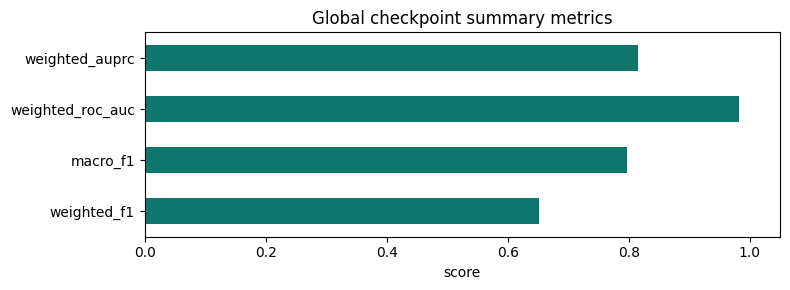

In [6]:
import matplotlib.pyplot as plt

if summary.exists():
    metric_cols = ["weighted_f1", "macro_f1", "weighted_roc_auc", "weighted_auprc"]
    values = pd.read_csv(summary).iloc[0][metric_cols].astype(float)
    ax = values.plot(kind="barh", figsize=(8, 3), color="#0f766e")
    ax.set_xlim(0, 1.05)
    ax.set_title("Global checkpoint summary metrics")
    ax.set_xlabel("score")
    plt.tight_layout()

## 5. Raw-data boundary check

In [7]:
data_like_files = sorted(
    list(Path("shared").rglob("*.csv"))
    + list(Path("shared").rglob("*.parquet"))
)
[str(path) for path in data_like_files]

[]